<a href="https://colab.research.google.com/github/alissonjsb4/applied-computational-intelligence/blob/main/homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOMEWORK 01 INTELIGÊNCIA COMPUTACIONAL APLICADA

Autores:

Icaro Adriano 609310 (Departamento de Engenharia de Teleinformatica)

Matheus Reis 571954 (Departamento de Engenharia de Teleinformatica)

Alisson Jaime matricula (Departamento de Engenharia de Teleinformatica)

Vinicius Alexandre Gomes do Nascimento 568594 (Departamento de Engenharia de Teleinformatica)

# DESCRIÇÃO DO DATASET

Como primeiro passo da análise, para conhecer o dataset de original, importa-se o dataset em formato csv, transformando-o em objeto dataframe do pandas, e printa-se o head do dataframe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/diabetes_risk_prediction_dataset.csv') # Lê um csv e transforma em um objeto rabela do pandas
saida = 'Diabetes_Risk_Score'

print(df.head()) # printa o head do dataframe

   Patient_ID   Age Gender        Country  Height_cm  Weight_kg   BMI  \
0           1  32.0   Male         Mexico      182.1       65.8  19.8   
1           2  42.0  Other   Saudi Arabia      148.5      101.2  45.9   
2           3  89.0  Other      Argentina      158.1        NaN  37.9   
3           4  87.0  Other  United States      190.9       95.9  26.3   
4           5  27.0  Other      Australia      156.9      101.9  41.4   

   Waist_Circumference_cm  Blood_Glucose  HbA1c  ...  Fatty_Liver  PCOS  \
0                    71.2           88.4   10.4  ...          Yes    No   
1                   121.8          247.3   11.3  ...          Yes   Yes   
2                   131.8          141.9    6.3  ...          Yes    No   
3                    99.1           90.1    7.4  ...           No    No   
4                    77.1           93.8   12.0  ...          Yes   Yes   

   Medication_Adherence   Work_Type  Residence_Type  Daily_Water_Intake_L  \
0                  Good     Retir

Em seguida, contamos o número de observações N, e de preditores D.

In [2]:
rows, columns = df.shape

print('número de linhas N: ', rows)
print('número de colunas: ', columns)


número de linhas N:  50000
número de colunas:  41


A partir dessas informações já nos é possível constatar que o número de observações é de 50000, que corresponde ao numero de linhas de um dataframe pandas, já o número de preditores depende de quantas variáveis queremos predizer, como o dataset não foi um dos contidos no exercício proposto, ainda faremos uma limpeza anterior, mas queremos predizer apenas o atributo Diabetes_Risk_Score, logo nosso número de preditores é inicialmente 40.

Para determinarmos as classes e sua distribuição iremos filtrar apenas os preditores qualitativos, e fazer a contagem dos diferentes valores destes.

In [3]:
preditores = df.drop(columns=[saida]) # Insere a coluna com nome da variavel saida em uma variavel preditores

def print_classes(dataframe):
    preditores_qualitativos = dataframe.select_dtypes(include=['object', 'category', 'string']) # pega os atributos com tipo especificado como argumento

    df_derretido = preditores_qualitativos.melt(var_name='Preditor', value_name='Valor') # transforma atributos em uma nova coluna cujos valores são os nomes dos atributos anteriores
    ocorrencias = df_derretido.value_counts(subset=['Preditor', 'Valor'])
    total_classes = len(ocorrencias)

    print("Distribuição de classes:")
    print(ocorrencias.to_string())
    print("Total de classes L:", total_classes)
    return

print_classes(preditores)

Distribuição de classes:
Preditor                    Valor                              
Doctor_Consultation_Needed  Yes                                    46426
Diabetes_Risk               High                                   36593
Heart_Disease               No                                     25288
Hypertension                Yes                                    25200
Fatty_Liver                 No                                     25155
Residence_Type              Urban                                  25129
Family_History_Diabetes     No                                     25076
PCOS                        No                                     25071
                            Yes                                    24929
Family_History_Diabetes     Yes                                    24924
Residence_Type              Rural                                  24871
Fatty_Liver                 Yes                                    24845
Hypertension                No     

Devido ao número excessivo de classes, todas as classes não relacionadas a nacionalidade e gênero serão removidas

In [4]:
preditores_quantitativos = preditores.select_dtypes(include=['int','float'])
preditores_qualitativos = preditores[['Country','Gender']]

preditores = pd.concat([preditores_quantitativos, preditores_qualitativos], axis=1)

print(preditores.head)

print_classes(preditores)

<bound method NDFrame.head of        Patient_ID   Age  Height_cm  Weight_kg   BMI  Waist_Circumference_cm  \
0               1  32.0      182.1       65.8  19.8                    71.2   
1               2  42.0      148.5      101.2  45.9                   121.8   
2               3  89.0      158.1        NaN  37.9                   131.8   
3               4  87.0      190.9       95.9  26.3                    99.1   
4               5  27.0      156.9      101.9  41.4                    77.1   
...           ...   ...        ...        ...   ...                     ...   
49995       49996  52.0      153.9      107.4  45.3                    75.9   
49996       49997  53.0      179.6       64.0  19.8                   114.5   
49997       49998  88.0      194.1       65.6  17.4                    96.1   
49998       49999  23.0      168.0       73.9  26.2                   131.4   
49999       50000  24.0      152.8       94.6  40.5                    66.1   

       Blood_Glucose 

Um número mais plausível de classes. Esse será o dataset utilizado para análise. Agora iremos extrair o número de preditores, o número de observações, e a distribuição das classes.

In [5]:
rows, columns = preditores.shape

print('Número de observações N: ', rows)
print('Número de preditores P: ', columns)
print('Distribuição de classses: ')
print_classes(preditores)

Número de observações N:  50000
Número de preditores P:  23
Distribuição de classses: 
Distribuição de classes:
Preditor  Valor         
Gender    Male              16718
          Other             16677
          Female            16605
Country   Malaysia           2083
          Russia             2071
          France             2068
          China              2065
          Canada             2050
          United Kingdom     2037
          Nigeria            2023
          Indonesia          2011
          Egypt              2010
          Spain              2007
          Mexico             1999
          Germany            1999
          South Korea        1997
          South Africa       1996
          Italy              1989
          Turkey             1984
          Japan              1983
          India              1974
          Bangladesh         1970
          Brazil             1967
          Pakistan           1959
          Australia          1956
          Uni

# ANÁLISE MONOVARIADA INCONDICIONAL
Por seguinte realizaremos uma análise monovariada sem discriminação por classes, extraindo a media, mediana, desvio padrão e assimetría de cada atributo, além de plotar seus histogramas e gráficos de caixa.

Column  Patient_ID data: 
Patient_ID mean:  25000.5
Patient_ID skewness:  0.0
Patient_ID standart deviation:  14433.90106658626


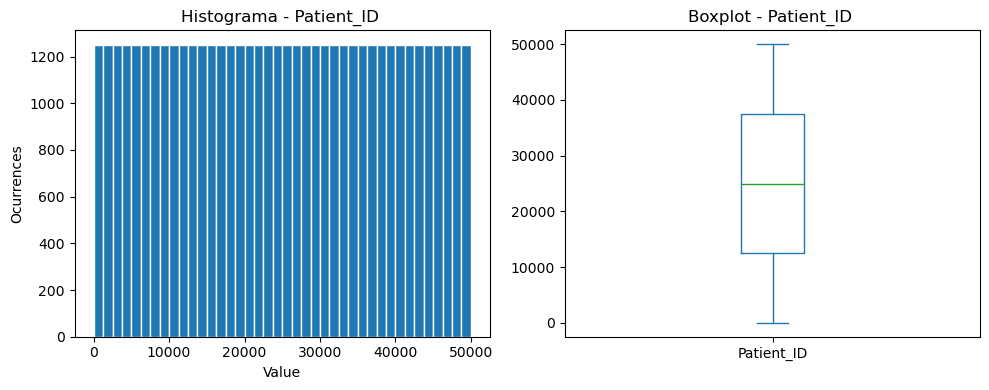

Column  Age data: 
Age mean:  53.87109872128962
Age skewness:  0.007512839687922029
Age standart deviation:  21.1301476973126


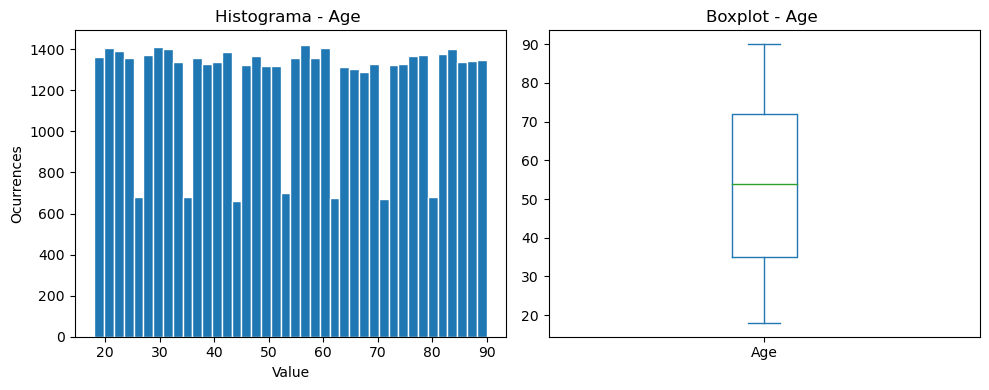

Column  Height_cm data: 
Height_cm mean:  170.01881415364997
Height_cm skewness:  0.0004208829321031421
Height_cm standart deviation:  14.457786611277559


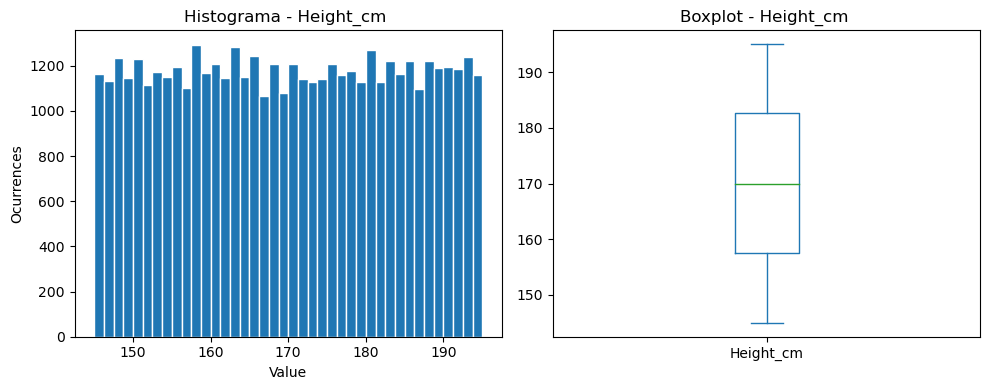

Column  Weight_kg data: 
Weight_kg mean:  87.45700284876058
Weight_kg skewness:  0.0042446766777343116
Weight_kg standart deviation:  24.50035783911258


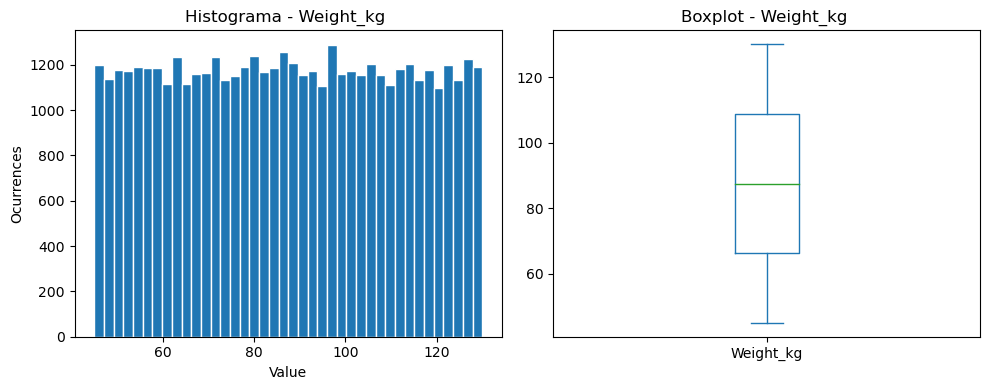

Column  BMI data: 
BMI mean:  30.924056
BMI skewness:  0.4317694129827958
BMI standart deviation:  10.290090661805685


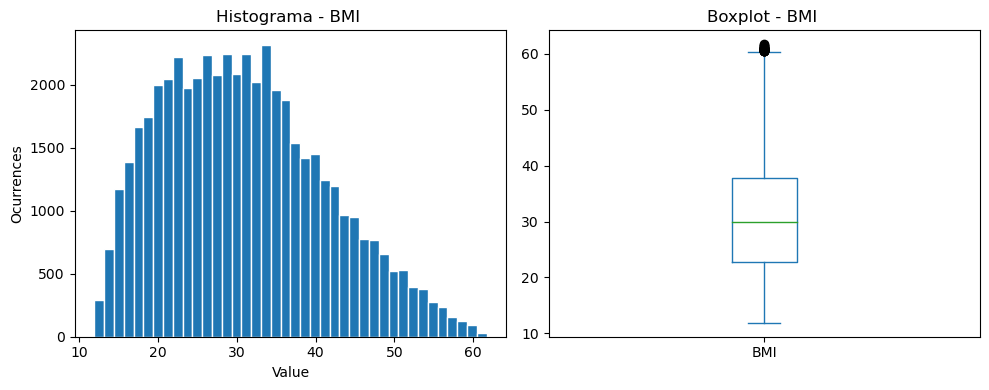

Column  Waist_Circumference_cm data: 
Waist_Circumference_cm mean:  99.96078999999997
Waist_Circumference_cm skewness:  0.009688430624564214
Waist_Circumference_cm standart deviation:  23.086578693652626


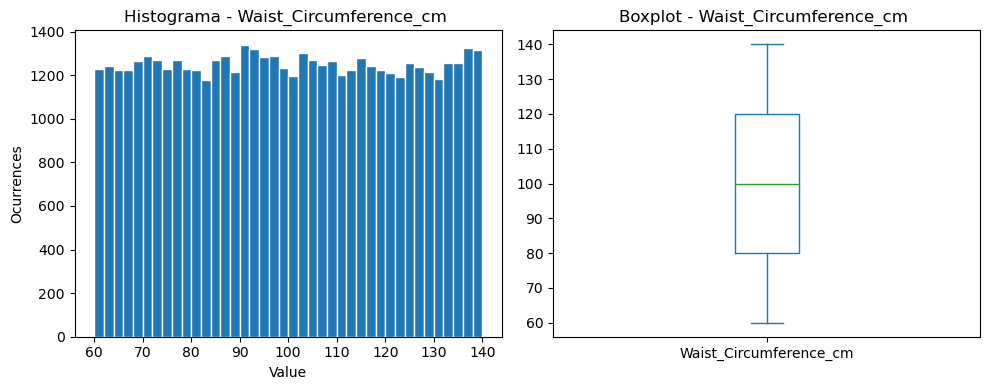

Column  Blood_Glucose data: 
Blood_Glucose mean:  159.90524459126038
Blood_Glucose skewness:  0.006298453438570136
Blood_Glucose standart deviation:  52.04057479292049


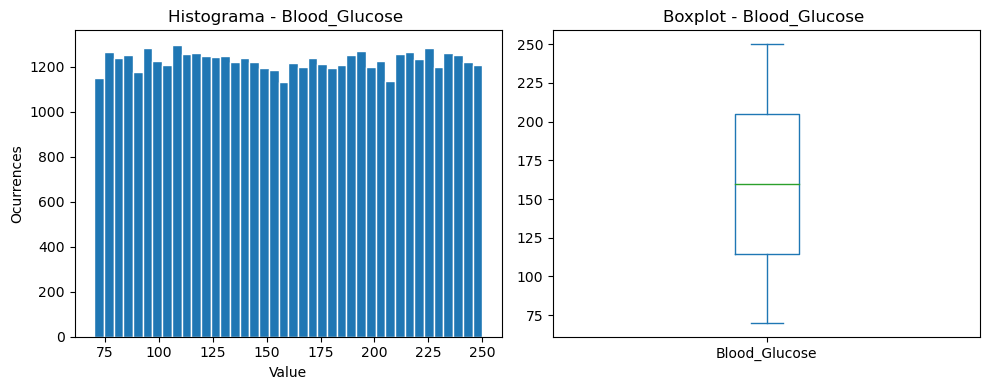

Column  HbA1c data: 
HbA1c mean:  8.488060633823345
HbA1c skewness:  0.0017092351750398538
HbA1c standart deviation:  2.313758112953104


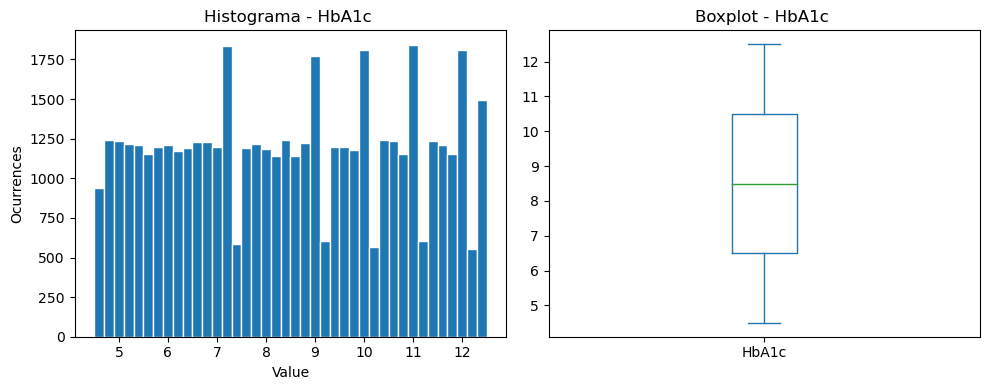

Column  Fasting_Blood_Sugar data: 
Fasting_Blood_Sugar mean:  142.607294
Fasting_Blood_Sugar skewness:  -0.0012380502410888924
Fasting_Blood_Sugar standart deviation:  44.681799465348675


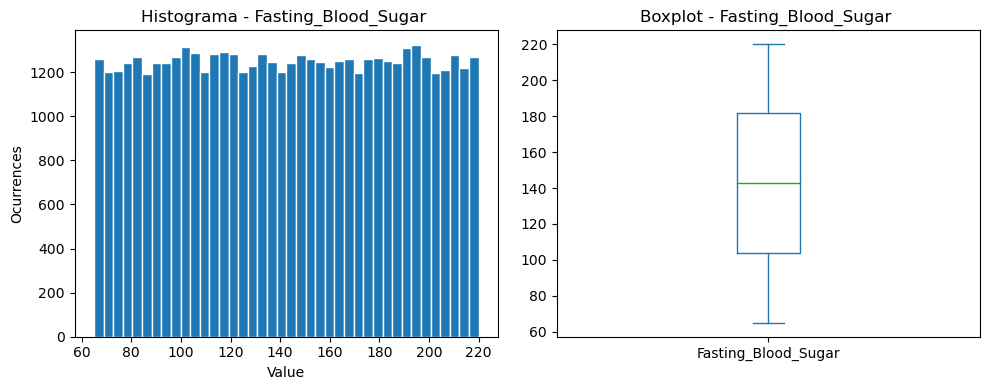

Column  Insulin_Level data: 
Insulin_Level mean:  23.476724
Insulin_Level skewness:  0.005540187089203176
Insulin_Level standart deviation:  12.403841345866477


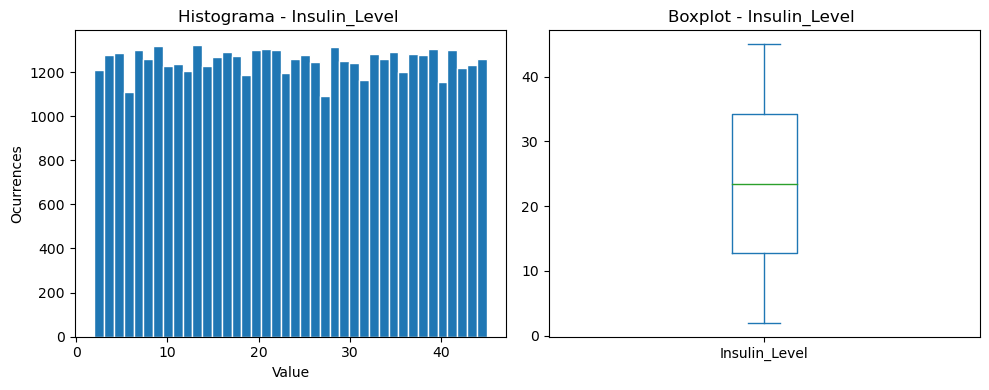

Column  Blood_Pressure_Systolic data: 
Blood_Pressure_Systolic mean:  140.17112
Blood_Pressure_Systolic skewness:  -0.0037586993782831287
Blood_Pressure_Systolic standart deviation:  29.16862310972327


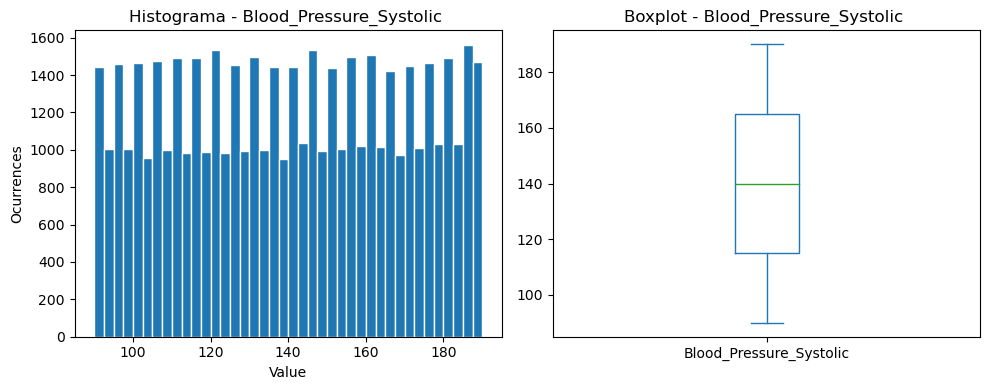

Column  Blood_Pressure_Diastolic data: 
Blood_Pressure_Diastolic mean:  90.039
Blood_Pressure_Diastolic skewness:  -0.00958019288838675
Blood_Pressure_Diastolic standart deviation:  17.575502751441828


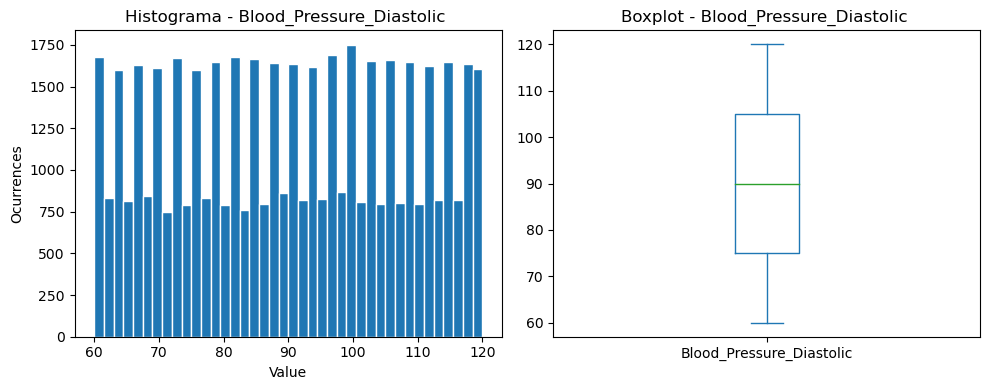

Column  Total_Cholesterol data: 
Total_Cholesterol mean:  220.16863469387758
Total_Cholesterol skewness:  -0.005052912473231308
Total_Cholesterol standart deviation:  57.793626169978666


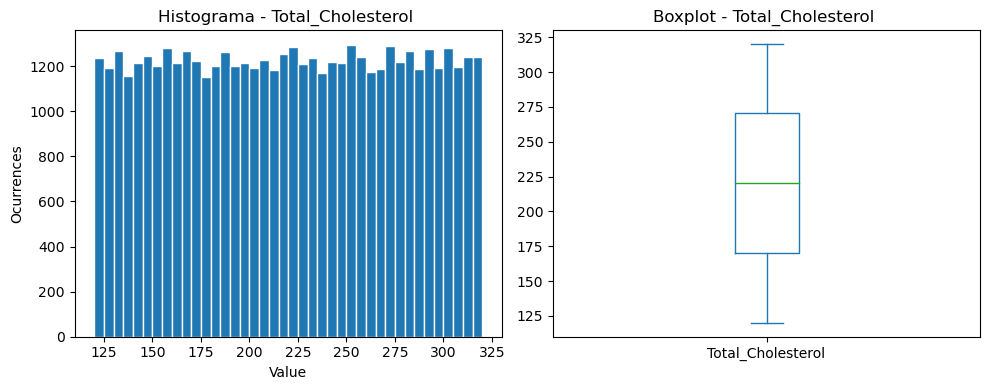

Column  HDL data: 
HDL mean:  57.371730612244896
HDL skewness:  0.003957540464458472
HDL standart deviation:  18.720696124390916


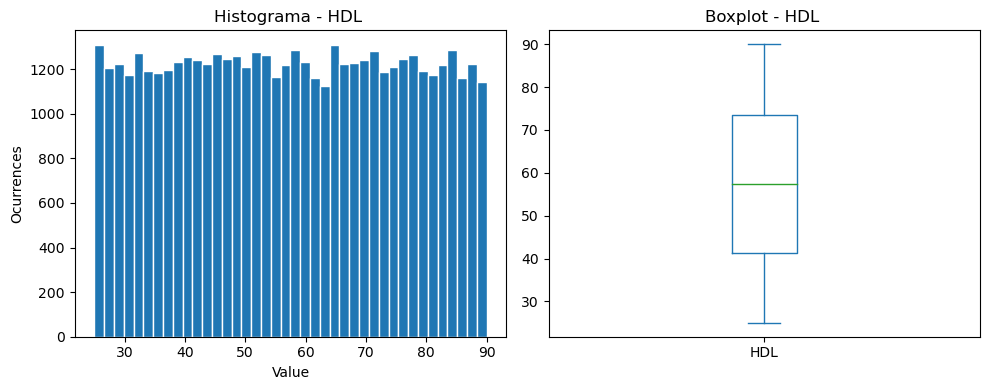

Column  LDL data: 
LDL mean:  135.01452448979592
LDL skewness:  -0.004072407154016737
LDL standart deviation:  49.13561345314557


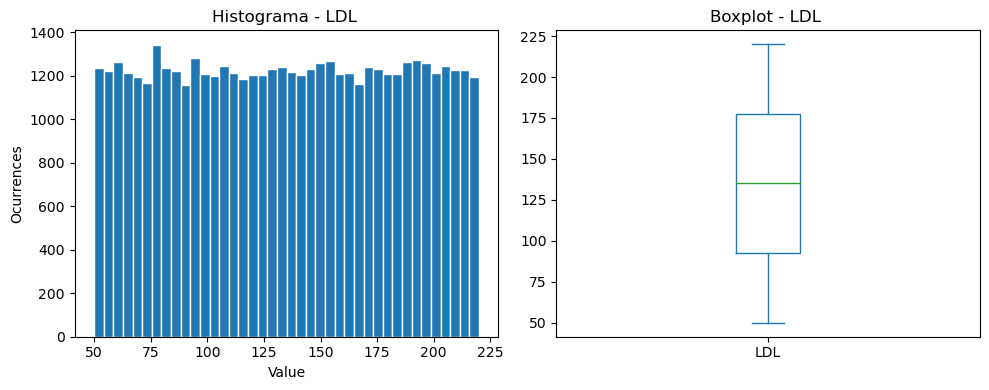

Column  Triglycerides data: 
Triglycerides mean:  229.54325918367346
Triglycerides skewness:  -6.94766743861743e-05
Triglycerides standart deviation:  98.23491079136728


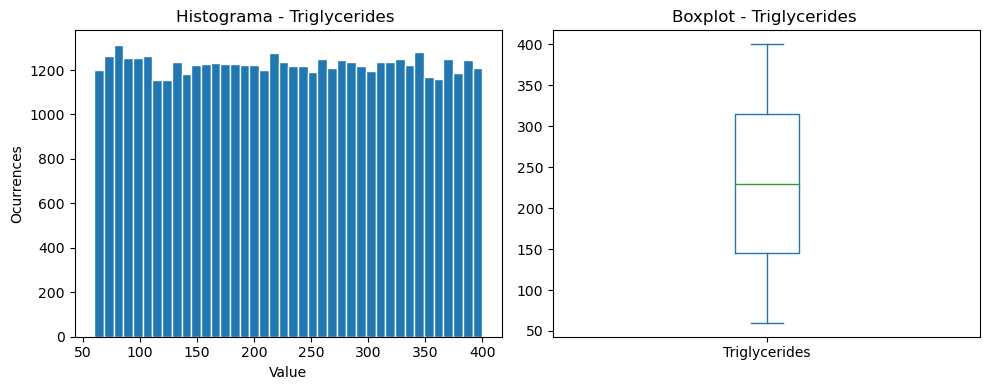

Column  Heart_Rate data: 
Heart_Rate mean:  85.12426
Heart_Rate skewness:  -0.014701556215837333
Heart_Rate standart deviation:  20.390334346623533


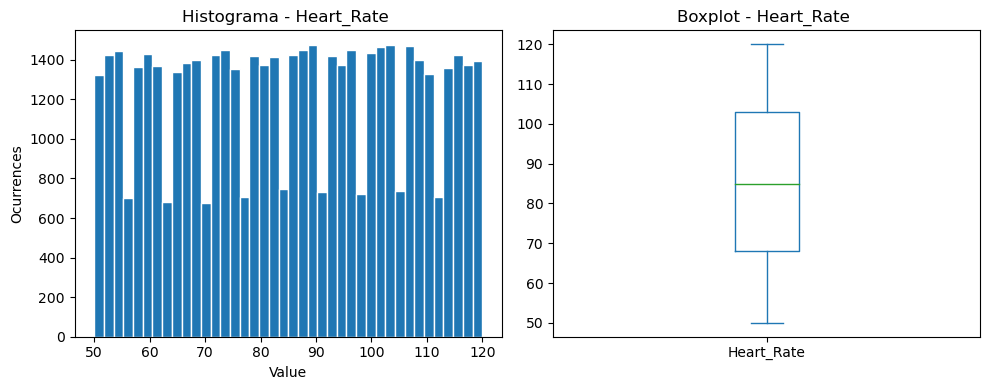

Column  Exercise_Hours_Per_Week data: 
Exercise_Hours_Per_Week mean:  5.017459590068321
Exercise_Hours_Per_Week skewness:  -0.009296615876169754
Exercise_Hours_Per_Week standart deviation:  2.8759219857896814


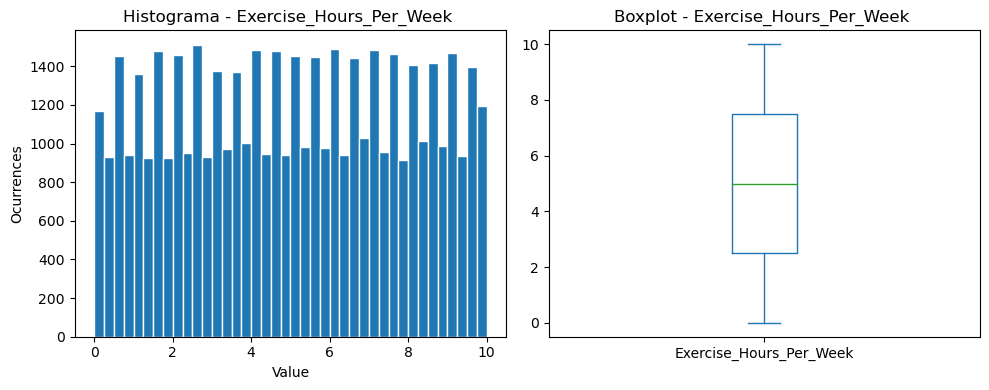

Column  Daily_Walking_Minutes data: 
Daily_Walking_Minutes mean:  89.93344158547755
Daily_Walking_Minutes skewness:  0.004699035128514406
Daily_Walking_Minutes standart deviation:  52.03464227071244


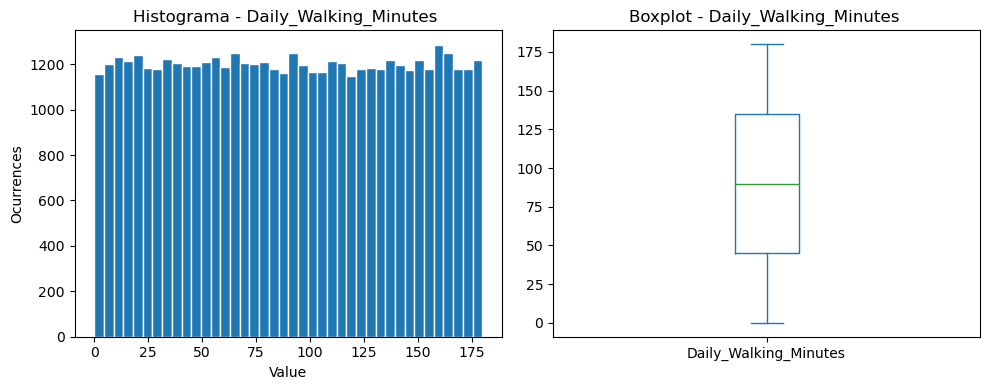

Column  Sleep_Hours data: 
Sleep_Hours mean:  6.500916991434466
Sleep_Hours skewness:  -0.005070828719186197
Sleep_Hours standart deviation:  2.0277929024217074


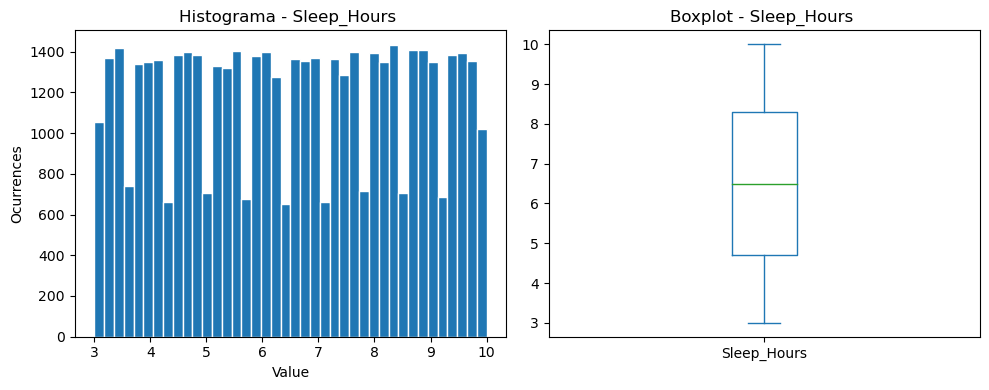

Column  Daily_Water_Intake_L data: 
Daily_Water_Intake_L mean:  2.9988420000000002
Daily_Water_Intake_L skewness:  0.0032439617943331245
Daily_Water_Intake_L standart deviation:  1.1522728035010954


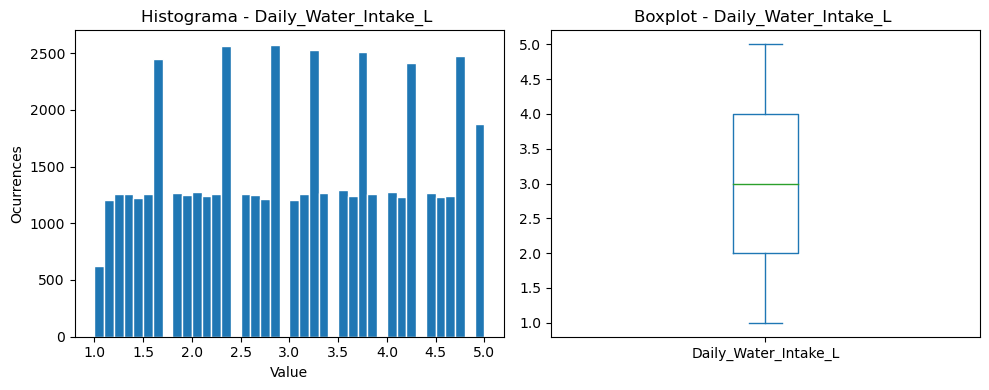

In [8]:
import matplotlib.pyplot as plt

def print_statistics(dataframe, column):
    mean = dataframe[column].mean()
    std = dataframe[column].std()
    skewness = dataframe[column].skew()

    
    print(column, 'mean: ', mean)
    print(column, 'skewness: ', skewness)
    print(column, 'standart deviation: ', std)
    return

def plot_hist_and_box(dataframe, column, group=''):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    dataframe[column].plot(kind='hist', ax=axes[0], bins=40, edgecolor='white', title=f'Histograma - {column} {group}')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Ocurrences')
    
    dataframe[column].plot(kind='box', ax=axes[1], title=f'Boxplot - {column} {group}')
    
    plt.tight_layout()
    plt.show()
    return

for columns in preditores_quantitativos:
    print('Column ', columns, 'data: ')
    print_statistics(preditores_quantitativos, columns)
    plot_hist_and_box(preditores_quantitativos, columns)

# ANÁLISE MONOVARIADA CONDICIONAL

In [ ]:
groups = ['Gender','Country']
nome_preditores_quantitativos = preditores.select_dtypes(include='number').columns

for group in groups:
    if group in preditores.columns:
        print(f'CONDITIONAL ANALYSIS ON {group} \n')
    
        for subgroup, subtable in preditores.groupby(group):
            for column in nome_preditores_quantitativos:
                print(f'Statistics and plots for {group} = {subgroup}')
                print_statistics(subtable, column)
                plot_hist_and_box(subtable, column, '- ' + subgroup)

# ANÁLISE BIVARIADA INCONDICIONAL

Com a análise monovariada feita, o próximo passo é olhar a relação entre os preditores dois a dois. Antes disso, tiramos a coluna Patient_ID de preditores_quantitativos: ela é só um identificador da linha, não representa nada fisiológico do paciente, então não faz sentido colocar ela nem na correlação nem nos scatter plots.

In [ ]:
preditores_sem_id = preditores_quantitativos.drop(columns=['Patient_ID'])
print(preditores_sem_id.columns)

Primeiro calculamos a correlação de Pearson entre todos os pares de preditores, mostrando tanto a tabela quanto a matriz como imagem (fica mais fácil de bater o olho e achar onde tem alguma relação linear mais forte, positiva ou negativa).

In [ ]:
correlacao = preditores_sem_id.corr()
print(correlacao)

fig, ax = plt.subplots(figsize=(12, 10))
imagem = ax.imshow(correlacao, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacao.columns)))
ax.set_yticks(range(len(correlacao.columns)))
ax.set_xticklabels(correlacao.columns, rotation=90)
ax.set_yticklabels(correlacao.columns)
fig.colorbar(imagem, ax=ax, label='Correlação de Pearson')
ax.set_title('Matriz de correlação dos preditores quantitativos')
plt.tight_layout()
plt.show()

Agora os scatter plots de cada par de preditores. São 20 preditores sem contar o ID, o que dá quase 200 combinações possíveis - plotar par por par ia deixar o notebook gigante e demorado de rodar, então usamos o scatter_matrix do próprio pandas, que já monta tudo numa figura só. Os pontos são coloridos por gênero (Male, Female, Other); não deu pra usar o país aqui porque com 27 valores as cores ficam tudo parecido e o gráfico vira uma bagunça.

In [ ]:
cores_genero = preditores['Gender'].map({'Male': 'tab:blue', 'Female': 'tab:red', 'Other': 'tab:green'})

pd.plotting.scatter_matrix(preditores_sem_id, figsize=(28, 28), c=cores_genero, alpha=0.3, s=10, diagonal='hist')
plt.suptitle('Scatter matrix dos preditores quantitativos - cor por gênero', y=0.9)
plt.show()

# ANÁLISE MULTIVARIADA - PCA

Pra fechar, fazemos a análise de componentes principais (PCA) na mão, sem usar sklearn nem nenhuma função de PCA pronta. A ideia é pegar os 20 preditores quantitativos e projetar eles em só 2 dimensões, mantendo o máximo de variância possível, pra dar pra visualizar tudo num scatter plot só. A única coisa que usamos do numpy é o cálculo de autovalor/autovetor (np.linalg.eigh) - o resto, padronização, matriz de covariância e a projeção, foi feito na mão mesmo, sem chamar nenhuma função de PCA.

In [ ]:
import numpy as np

dados_pca = preditores_sem_id.dropna() # a matriz de covariância não pode ter NaN, e o dataset tem bastante linha com valor faltante
classes_pca = preditores.loc[dados_pca.index, 'Gender']

print('Linhas antes do dropna: ', len(preditores_sem_id))
print('Linhas depois do dropna: ', len(dados_pca))

medias = dados_pca.mean()
desvios = dados_pca.std()
dados_padronizados = (dados_pca - medias) / desvios # padroniza pra media 0 e desvio padrão 1, já que os preditores estão em escalas bem diferentes (BMI vai até uns 50, Blood_Glucose passa de 200) e sem isso quem tem maior escala ia dominar a análise

matriz_covariancia = (dados_padronizados.T @ dados_padronizados) / (len(dados_padronizados) - 1)

autovalores, autovetores = np.linalg.eigh(matriz_covariancia)

ordem = np.argsort(autovalores)[::-1] # eigh devolve em ordem crescente, então invertemos pra ficar do maior autovalor pro menor
autovalores = autovalores[ordem]
autovetores = autovetores[:, ordem]

print('Autovalores, do maior pro menor:')
print(autovalores)
print('Variância explicada pelas 2 primeiras componentes: ', (autovalores[0] + autovalores[1]) / autovalores.sum())

Com os autovetores em mãos, pegamos só os 2 primeiros (associados aos 2 maiores autovalores) e projetamos os dados padronizados nessas 2 direções. É essa projeção que vira o scatter plot final, de novo colorido por gênero.

In [ ]:
componentes_principais = autovetores[:, :2]
dados_projetados = dados_padronizados.values @ componentes_principais

cores_pca = classes_pca.map({'Male': 'tab:blue', 'Female': 'tab:red', 'Other': 'tab:green'})

plt.figure(figsize=(8, 6))
plt.scatter(dados_projetados[:, 0], dados_projetados[:, 1], c=cores_pca, alpha=0.3, s=10)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Projeção PCA (2 primeiras componentes) - cor por gênero')
plt.show()